# contrasts_melt_pond_paper

Figures for paper about melt ponds on CONTRASTS

@author: David Clemens-Sewall

Anticipated figures:
 
 a) Overview of pond and bare ice properties
 
 b) Example photo of pond cores, ice profiles, pond photos
 
 c) Salinity and density profiles
 
 d) Comparison of per-category ice thickness with pond depth at contrasts vs sealvl ponds and pond area fraction vs depth


In [1]:
import os
import glob
import re
import warnings
import datetime

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns

from openpyxl import load_workbook
from matplotlib.colors import Normalize
from matplotlib.ticker import FixedFormatter

%matplotlib inline

In [2]:
# Set default color cycle:
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["dodgerblue", "darkgray"]) 

In [3]:
# Paths
ic_data_root = os.path.join('..', 'data', 'ice_coring')
transect_data_root = os.path.join('..', 'data', 'transects_from_max')

In [4]:
# Ice core data is very complicated, especially the vertical reference frame
# Define a class for representing ice cores
class IceCore:
    """
    Class representing data from an individual ice core.

    Attributes:
        station (str): Station number (1, 2, or 3) as a string.
        visit (str): Visit letter ([a-d]).
        file_path (str): Path to the xlsx file containing core data.
        core (str): Name of the core.
        site (str): Site name
        timestamp (datetime.datetime): Timestamp for the core.
        hi (float): Ice thickness (measured by a thickness gauge) in meters.
        draft (float): Draft (measured by a thickness gauge) in meters.
        length (float): Total core length in meters.
        freeboard (float): Freeboard (ice thickness - draft) in meters.
        snow_depths (array): Array of snow depths in meters.
        hs (float): Mean snow depth in meters.
        hp (float): Pond depth in meters.
        ponded (bool): Whether the ice was ponded.
        age (str): Sea ice age.
        data (Pandas.DataFrame): Dataframe containing data for this core.
        comments (Pandas.DataFrame): Dataframe containing comments for this core.
        units (dict): Mapping of variable names in self.data to units.
        variables (list): List of data variables that this ice core has.
    """
    
    def __init__(self, station, visit, file_path):
        """
        Initialize an IceCore object and load basic core metadata.

        Parameters:
            station (str): Station number (1, 2, or 3) as a string.
            visit (str): Visit letter ([a-d]).
            file_path (str): Path to the xlsx file containing core data.
        """
        # Store attributes
        self.station = station
        self.visit = visit
        self.file_path = file_path

        # Open excel workbook
        wb = load_workbook(file_path, read_only=True, data_only=True)
        ws_core = wb['metadata-core']
        ws_coring = wb['metadata-coring']

        # Get the core name from the workbook and check that it matches the filename
        core_fn = os.path.basename(file_path)[:-5]
        core_wb = ws_core['C1'].value
        if core_fn != core_wb:
            warnings.warn(f"Core name from filename does not match workbook, using core name from filename: {core_fn}",
                          category=RuntimeWarning)
        self.core = core_fn
        self.site = ws_coring['C4'].value

        ## Get basic parameters
        # time
        if ws_core['D2'].value == 'UTC':
            tzinfo = datetime.timezone.utc
        else:
            raise RuntimeError('Timezone is not UTC, need to implement support for other timezones')
        date = ws_core['C2'].value
        time = ws_core['C3'].value
        if time is None:
            time = ws_coring['C13'].value
        if time is None:
            warnings.warn(f"{core_fn} is missing time info setting to 12 utc")
            time = datetime.time(hour=12)
        self.timestamp = datetime.datetime.combine(date, time, tzinfo=tzinfo)
        # ice measurements
        self.hi = ws_core['C7'].value
        self.draft = ws_core['C8'].value
        self.freeboard = ws_core['C9'].value
        self.length = ws_core['C10'].value
        if self.length is None:
            raise RuntimeError(f"{self.core} is missing core length")
        # Account for potential missing core data
        if self.hi is None:
            warnings.warn(f"{self.core} is missing ice thickness, using core length",
                          category=RuntimeWarning)
            self.hi = self.length
        if (self.draft is None) and (self.freeboard is None):
            warnings.warn(f"{self.core} is missing freeboard and draft",
                         category=RuntimeWarning)
        elif self.freeboard is None:
            self.freeboard = self.hi - self.draft
        elif self.draft is None:
            self.draft = self.hi - self.freeboard
        self.age = ws_coring['C20'].value
        # snow measurements
        for value in ws_coring.iter_rows(min_row=16, max_row=16, min_col=3, max_col=8, values_only=True):
            self.snow_depths = np.array(value, dtype=float)
        if np.isnan(self.snow_depths).all():
            self.hs = 0
        else:
            self.hs = np.nanmean(self.snow_depths)
        # pond measurements
        self.hp = ws_coring['C19'].value
        if self.hp is None:
            self.ponded = False
            self.hp = 0
        else:
            self.ponded = True

        ## Initialize the data and comments dataframes
        idx = pd.MultiIndex.from_tuples([], names=('variable', 'depth_top', 'depth_bottom', 'depth_center'))
        self.data = pd.DataFrame(columns=['value'], index=idx)
        self.comments = pd.DataFrame(columns=['description', 'comment'], index=idx)
        self.units = {}
        self.variables = []
        wb.close()

    def load_salinity(self):
        """Loads salinity data if present in file."""

        # Get temperature sheet
        wb = load_workbook(self.file_path, read_only=True, data_only=True)
        ws = wb['SALO18']

        # If there is no data at all in the temperature sheet, return
        if ws['A5'].value is None:
            return
        # Read in values
        ls_d_t = []
        ls_d_b = []
        ls_s = []
        ls_c = []
        for row in ws.iter_rows(min_row=5, min_col=1, max_col=14):
            d_t = row[0].value
            if d_t is None:
                break
            else:
                ls_d_t.append(d_t)
                ls_d_b.append(row[1].value)
                ls_s.append(row[4].value)
                ls_c.append(row[13].value)
        # Create temporary dataframes and concatenate
        df_data_temp = pd.DataFrame({'variable': 'salinity',
                                     'depth_top': ls_d_t,
                                     'depth_bottom': ls_d_b,
                                     'depth_center': np.nan,
                                     'value': ls_s})
        df_data_temp['depth_center'] = (df_data_temp['depth_top'] + df_data_temp['depth_bottom'])/2.0
        df_data_temp.set_index(['variable', 'depth_top', 'depth_bottom', 'depth_center'],
                               inplace=True)
        df_comm_temp = pd.DataFrame({'variable': 'salinity',
                                     'depth_top': ls_d_t,
                                     'depth_bottom': ls_d_b,
                                     'depth_center': np.nan,
                                     'description': '',
                                     'comment': ls_c})
        df_comm_temp['depth_center'] = (df_comm_temp['depth_top'] + df_comm_temp['depth_bottom'])/2.0
        df_comm_temp.set_index(['variable', 'depth_top', 'depth_bottom', 'depth_center'],
                               inplace=True)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            self.data = pd.concat([self.data, df_data_temp])
            self.comments = pd.concat([self.comments, df_comm_temp])
        # Update variables and units fields
        self.variables.append('salinity')
        self.units['salinity'] = ws['E4'].value
        wb.close()

    def load_densimetry(self):
        """Loads densimetry data if present in file."""

        # Get temperature sheet
        wb = load_workbook(self.file_path, read_only=True, data_only=True)
        ws = wb['Density-densimetry']

        # If there is no data at all in the temperature sheet, return
        if ws['A4'].value is None:
            return
        # Read in values
        ls_d_t = []
        ls_d_b = []
        ls_r = []
        ls_c = []
        for row in ws.iter_rows(min_row=4, min_col=1, max_col=8):
            d_t = row[0].value
            if d_t is None:
                break
            else:
                ls_d_t.append(d_t)
                ls_d_b.append(row[1].value)
                ls_r.append(row[6].value)
                ls_c.append(row[7].value)
        # Create temporary dataframes and concatenate
        df_data_temp = pd.DataFrame({'variable': 'density',
                                     'depth_top': ls_d_t,
                                     'depth_bottom': ls_d_b,
                                     'depth_center': np.nan,
                                     'value': ls_r})
        df_data_temp['depth_center'] = (df_data_temp['depth_top'] + df_data_temp['depth_bottom'])/2.0
        df_data_temp.set_index(['variable', 'depth_top', 'depth_bottom', 'depth_center'],
                               inplace=True)
        df_comm_temp = pd.DataFrame({'variable': 'density',
                                     'depth_top': ls_d_t,
                                     'depth_bottom': ls_d_b,
                                     'depth_center': np.nan,
                                     'description': '',
                                     'comment': ls_c})
        df_comm_temp['depth_center'] = (df_comm_temp['depth_top'] + df_comm_temp['depth_bottom'])/2.0
        df_comm_temp.set_index(['variable', 'depth_top', 'depth_bottom', 'depth_center'],
                               inplace=True)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            self.data = pd.concat([self.data, df_data_temp])
            self.comments = pd.concat([self.comments, df_comm_temp])
        # Update variables and units fields
        self.variables.append('density')
        self.units['density'] = ws['G3'].value
        wb.close()

    def load_temperature(self):
        """Loads temperature data if present in file."""

        # Get temperature sheet
        wb = load_workbook(self.file_path, read_only=True, data_only=True)
        ws = wb['TEMP']

        # If there is no data at all in the temperature sheet, return
        if ws['A4'].value is None:
            return
        # Read in values
        ls_d_c = []
        ls_t = []
        ls_c = []
        for row in ws.iter_rows(min_row=4, min_col=1, max_col=3):
            d_c = row[0].value
            if d_c is None:
                break
            else:
                ls_d_c.append(d_c)
                ls_t.append(row[1].value)
                ls_c.append(row[2].value)
        # Create temporary dataframes and concatenate
        df_data_temp = pd.DataFrame({'variable': 'temperature',
                                     'depth_top': np.nan,
                                     'depth_bottom': np.nan,
                                     'depth_center': ls_d_c,
                                     'value': ls_t})
        df_data_temp.set_index(['variable', 'depth_top', 'depth_bottom', 'depth_center'],
                               inplace=True)
        df_comm_temp = pd.DataFrame({'variable': 'temperature',
                                     'depth_top': np.nan,
                                     'depth_bottom': np.nan,
                                     'depth_center': ls_d_c,
                                     'description': '',
                                     'comment': ls_c})
        df_comm_temp.set_index(['variable', 'depth_top', 'depth_bottom', 'depth_center'],
                               inplace=True)
        self.data = pd.concat([self.data, df_data_temp])
        self.comments = pd.concat([self.comments, df_comm_temp])
        # Update variables and units fields
        self.variables.append('temperature')
        self.units['temperature'] = ws['B3'].value
        wb.close()

    def plot_profile(self, ax, variable, z_ref='ice top', z_scale='absolute',
                     kind='center', linestyle='solid', color = 'C0',
                    markersize=3):
        """
        Plots a profile of a single variable from the ice core following various conventions

        Parameters:
            ax (Matplotlib Axes): Axes to plot on.
            variable (str): Variable to plot, must be in self.data
            z_ref (str): Vertical reference for profile, must be one of ['ice top',
                'sea surface', 'pond surface']. The default is 'ice top'.
            z_scale (str): How to scale z values, must be one of ['absolute', 
                'relative']. The default is 'absolute'.
            kind (str): Whether to plot values at the 'center' of ice segments
                or as a line spanning entire segment ('segment') the default is 'center'.
            linestyle (str): Line style for line.
            color (color for Matplotlib): Line color.
            markersize (float): Marker size

        Returns:
            Handle from matplotlib object.
        """
        
        # z_ref_dict for converting z_ref into z values
        z_ref_dict = {'ice top': 0,
                      'sea surface': self.freeboard,
                      'pond surface': -self.hp
                     }
        z_unit_dict = {'absolute': 'm',
                       'relative': '1',
                      }
        # Get data
        df_plot = self.data.query('variable == @variable').reset_index()
        # Adjust for z-reference
        df_plot['z_t'] = z_ref_dict[z_ref] - df_plot['depth_top']
        df_plot['z_b'] = z_ref_dict[z_ref] - df_plot['depth_bottom']
        df_plot['z_c'] = z_ref_dict[z_ref] - df_plot['depth_center']
        # If scale is relative, adjust for relative vertical position
        if z_scale == 'relative':
            if z_ref == 'pond surface':
                z_top = 0
                z_bottom = -self.hp - self.length
            else:
                z_top = z_ref_dict[z_ref]
                z_bottom = z_top - self.length
            df_plot['z_t'] = (df_plot['z_t'] - z_bottom) / (z_top - z_bottom)
            df_plot['z_b'] = (df_plot['z_b'] - z_bottom) / (z_top - z_bottom)
            df_plot['z_c'] = (df_plot['z_c'] - z_bottom) / (z_top - z_bottom)
        elif z_scale != 'absolute':
            raise RuntimeError('invalid value for z_scale')
        
        # Plot values
        if kind == 'segment':
            h = ax.vlines(df_plot['value'], df_plot['z_b'], df_plot['z_t'],
                      colors=color, linestyles=linestyle, label=self.core)
            ax.plot(df_plot['value'], df_plot['z_b'], color=color,
                    marker='o', linestyle='none', label=None,
                   markersize=markersize)
            ax.plot(df_plot['value'], df_plot['z_t'], color=color,
                    marker='o', linestyle='none', label=None,
                   markersize=markersize)
        elif kind == 'center':
            h = ax.plot(df_plot['value'], df_plot['z_c'],
                        color=color, linestyle=linestyle, label=self.core,
                        marker='o', markersize=markersize)
        else:
            raise RuntimeError('invalid value for kind')

        ax.set_ylabel(f'{z_scale} height from {z_ref} ({z_unit_dict[z_scale]})')
        ax.set_xlabel(f'{variable} ({self.units[variable]})')

        return h

    def bulk_property(self, variable):
        """
        Return the bulk (vertically-averaged) property.

        Paramters:
            variable (str): Variable name to compute bulk property.

        Returns:
            (float) bulk property.
        """

        if not variable in self.units:
            raise RuntimeError(f'{variable} not found in {self.core}')

        df_temp = self.data.query('variable == @variable').reset_index()
        df_temp['thickness'] = df_temp.depth_bottom - df_temp.depth_top
        
        return (df_temp['value']*df_temp['thickness']).sum()/df_temp['thickness'].sum()

    def total_salt(self, density=None, phi_connected=0):
        """
        Return the total amount of salk (kg/m2) in the ice column.

        Parameters:
            density (float): Disconnected ice density (g/cm3). If None,
                use density data from the core. The default is None.
            phi_connected (float): The volume fraction of the ice that is
                fully connected to the ocean, and hence unmeasured in a core
                and not part of the ice itself. The default is 0.

        Returns:
            (float) Total mass of salt in ice column (kg/m2)
        """

        # Check data is present
        if not 'salinity' in self.units:
            raise RuntimeError(f'{self.core} does not have salinity data')
        if (density is None) and (not 'density' in self.units):
            raise RuntimeError(f'{self.core} does not have requested density data')

        # Create dataframe for calculation
        if density is None:
            df_temp = self.data.query('variable in ["salinity", "density"]').reset_index(
                'variable').pivot(columns='variable', values='value')
            if df_temp.isnull().values.any():
                raise NotImplementedError(f'mismatched or missing density and salinity in {core}')
        else:
            df_temp = self.data.query('variable == "salinity"').reset_index(
                'variable', drop=True).rename(columns={'value': 'salinity'})
            df_temp['density'] = density
        df_temp = df_temp.reset_index()
        df_temp['thickness'] = df_temp.depth_bottom - df_temp.depth_top

        # Return value
        # [density] g/cm3 * 1kg/1e3g * 1e6cm3/1m3 * [thickness] m * [salinity] g/kg * 1kg/1e3g * [1 - phi_connected]
        return (df_temp.density*df_temp.thickness*df_temp.salinity*(1 - phi_connected)).sum()

In [5]:
# Load all ice core data
stations = ['1', '2', '3']
visits = ['a', 'b', 'c', 'd']

# Load each core into a dataframe
ls_s = []
ls_v = []
ls_name = []
ls_icecore = []
for station in stations:
    for visit in visits:
        filepaths = glob.glob(os.path.join(ic_data_root, f"IceStation{station}{visit}", '**', '[!~]*.xlsx'))
        for fp in filepaths:
            if os.path.basename(fp)[:3] == 'Ice':
                continue
            # load core properties
            try:
                ic = IceCore(station, visit, fp)
            except RuntimeError as err:
                print(err)
                continue
            # Load data if present
            ic.load_temperature()
            ic.load_salinity()
            ic.load_densimetry()
            # Append to lists
            ls_s.append(station)
            ls_v.append(visit)
            ls_name.append(ic.core)
            ls_icecore.append(ic)

df_cores = pd.DataFrame({'station': ls_s,
                         'visit': ls_v,
                         'name': ls_name,
                         'core': ls_icecore})
df_cores = df_cores.set_index(['station', 'visit', 'name'])

df_cores['timestamp'] = datetime.datetime(2025, 1, 1, tzinfo=datetime.timezone.utc)
for i in np.arange(df_cores.shape[0]):
    df_cores.iat[i,1] = df_cores.iat[i,0].timestamp

C:\Users\dacl4713\AppData\Local\Temp\ipykernel_20244\1002622467.py:52: RuntimeWarning: Core name from filename does not match workbook, using core name from filename: 20250710-PS149_13-1-SI_corer_9cm-016-FYI-REP
  warnings.warn(f"Core name from filename does not match workbook, using core name from filename: {core_fn}",
C:\Users\dacl4713\AppData\Local\Temp\ipykernel_20244\1002622467.py:254: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.data = pd.concat([self.data, df_data_temp])
C:\Users\dacl4713\AppData\Local\Temp\ipykernel_20244\1002622467.py:52: RuntimeWarning: Core name from filename does not match workbook, using core name from filename: 20250710-PS149_13-1-SI_corer_9cm-017-FYI-RHO
  warnings.warn(f"Core name from filename does no

20250715-PS149_16-1-SI_corer_9cm-018-FYI-REP is missing core length


C:\Users\dacl4713\AppData\Local\Temp\ipykernel_20244\1002622467.py:254: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.data = pd.concat([self.data, df_data_temp])
C:\Users\dacl4713\AppData\Local\Temp\ipykernel_20244\1002622467.py:80: RuntimeWarning: 20250730-PS149_25-1-SI_corer_9cm-020-SMYI-T is missing ice thickness, using core length
  warnings.warn(f"{self.core} is missing ice thickness, using core length",
C:\Users\dacl4713\AppData\Local\Temp\ipykernel_20244\1002622467.py:84: RuntimeWarning: 20250730-PS149_25-1-SI_corer_9cm-020-SMYI-T is missing freeboard and draft
  warnings.warn(f"{self.core} is missing freeboard and draft",
C:\Users\dacl4713\AppData\Local\Temp\ipykernel_20244\1002622467.py:254: FutureWarning: The behavior of Data

In [6]:
# Load transect summary
df_trn = pd.read_excel(os.path.join(transect_data_root, 'pond_ice_statistics.xlsx'), 
                       index_col=0, usecols='A:E,G:K', nrows=6)
# Reformat a bit
rename_dict = {'pond fraction': 'ap', 
               'mean pond depth': 'hp', 
               'mean snow / SSL depth': 'hs',
               'mean SIT *': 'hi', 
               'mean unponded SIT **': 'hi_b', 
               'mean under-pond SIT **': 'hi_p'}
df_trn = df_trn.rename(index=rename_dict).T.reset_index()
df_trn['floe'] = df_trn['index'].str[0]
df_trn['visit'] = df_trn['index'].str[1]
df_trn = df_trn.set_index(['floe', 'visit']).drop(columns='index')
df_trn['hp'] *= 0.01
df_trn['hs'] *= 0.01

In [7]:
# !!!!!!!!!!!!!!!!! TODO: ask Max what to use for ice thickness (or snow/pond+ice thickness)
# Load transect data

floe_visit = ['1a', '1b', '1c', '2a', '2c', '2d', '3a', '3b', '3c']

ls_df = []
for fv in floe_visit:
    ls_df.append(pd.read_csv(os.path.join(transect_data_root, f"collocated_GEM_MagnaProbe_floe{fv}_1m.csv")))
    ls_df[-1]['floe'] = fv[0]
    ls_df[-1]['visit'] = fv[1]

df_trn_all = pd.concat(ls_df)
df_trn_all.drop(columns=['spatial_distance_m', 'n_gem_averaged', 
                         'f1525Hz_hcp_i', 'f1525Hz_hcp_q', 'f5325Hz_hcp_i',
                         'f5325Hz_hcp_q', 'f18325Hz_hcp_q', 'f63025Hz_hcp_i',
                         'f63025Hz_hcp_q', 'f93075Hz_hcp_i', 'f93075Hz_hcp_q'],
               inplace=True)
# use 'f18325Hz_hcp_i' for total (snow/pond+ice thickness), those means are consistent with the histograms from Max
df_trn_all.rename(columns={'f18325Hz_hcp_i': 'TotalThickness'}, inplace=True)
df_trn_all['SnowDepth'] *= 0.01
df_trn_all['PondDepth'] *= 0.01

# on 16 (out of ~5K) occasions both SnowDepth and PondDepth are notna let's make those ponds
df_trn_all.loc[df_trn_all['PondDepth'].notna(), 'SnowDepth'] = np.nan

# Eliminate negative snow depths (93/5000)
df_trn_all = df_trn_all.loc[~(df_trn_all.SnowDepth<0), :]

# Ice thickness is the Total Thickness minus the snow or pond depth
df_trn_all['IceThickness'] = df_trn_all.TotalThickness - df_trn_all[['SnowDepth', 'PondDepth']].sum(axis=1, skipna=True)

# Eliminate nonexistent ice thickness rows (19/5000)
df_trn_all = df_trn_all.loc[df_trn_all.IceThickness.notna(), :]

## a) Overview of pond and bare ice properties

In [22]:
## Summarize bulk core properties
# Check bulk cores before future analysis!!!!!
# Maybe think about counting the r1b 'lead' ice as melt pond ice? That ice was almost certainly ponded at some point between the visits?
# Maybe check the camera buoy to see if there's evidence of this?
cores_exclude = ['20250726-PS149_21-1-SI_corer_9cm-020-FYI-lead-T',
                 '20250726-PS149_21-1-SI_corer_9cm-021-FYI-lead-SALO18',
                 '20250726-PS149_21-1-SI_corer_9cm-022-FYI-lead-RHO',
                 '20250730-PS149_25-1-SI_corer_9cm-021-SMYI-RHO',
                 '20250814-PS149_36-1-SI_corer_9cm-021-SYI-SALO18',
                ]

ls_s = []
ls_r = []
ls_p = []
ls_a = []
df_temp = df_cores.query('name not in @cores_exclude')
for idx, ic in df_temp.core.items():
    if 'salinity' in ic.units:
        ls_s.append(ic.bulk_property('salinity'))
    else:
        ls_s.append(np.nan)
    if 'density' in ic.units:
        ls_r.append(ic.bulk_property('density'))
    else:
        ls_r.append(np.nan)
    ls_p.append(ic.ponded)
    ls_a.append(ic.age)
df_bulk = pd.DataFrame({'salinity': ls_s, 'density': ls_r, 
                        'ponded': ls_p, 'age': ls_a}, index=df_temp.index)
df_bulk.set_index(['ponded', 'age'], append=True, inplace=True)
df_bulk = df_bulk.melt(ignore_index=False).dropna(how='any')
df_bulk = df_bulk.reset_index().drop(columns=['name']).groupby(
    by=['station', 'visit', 'ponded', 'age', 'variable']).mean()

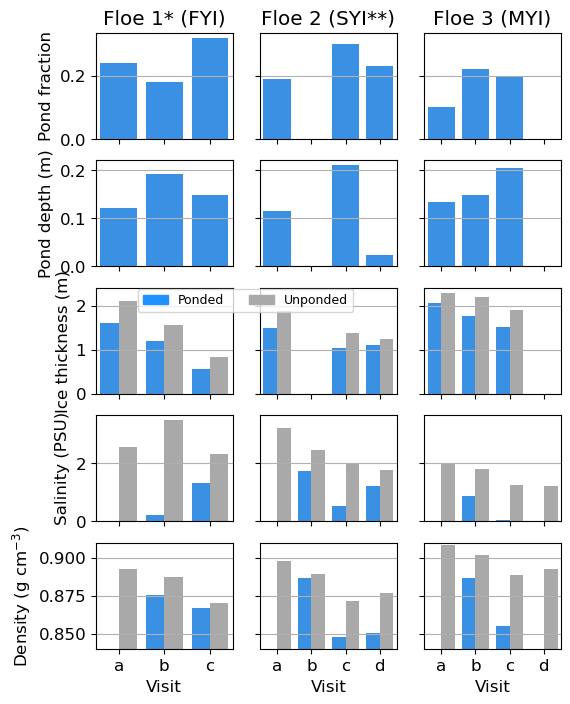

In [29]:
## Plot pond ice prop summary
mpl.rcParams["font.size"] = 12
l_fs = 9

f, axs = plt.subplots(5, 3, sharey='row', sharex='col', figsize=(6,8))

for i in np.arange(3):
    floe = str(i+1)
    df_temp = df_bulk.xs((floe, 'salinity'), level=['station', 'variable'])
    sns.barplot(df_temp, x='visit', y='value', hue='ponded', 
                hue_order=[True, False], ax=axs[3,i], legend=False)
    df_temp = df_bulk.xs((floe, 'density'), level=['station', 'variable'])
    sns.barplot(df_temp, x='visit', y='value', hue='ponded', 
                hue_order=[True, False], ax=axs[4,i], legend=False)
    df_temp = df_trn.xs(floe)
    df_temp = df_temp[['hi_b', 'hi_p']].melt(ignore_index=False, var_name='variable')
    sns.barplot(df_temp, x='visit', y='value', hue='variable', 
                hue_order=['hi_p', 'hi_b'], ax=axs[2,i], legend=False)
    df_temp = df_trn.xs(floe)
    sns.barplot(df_temp, x='visit', y='ap', ax=axs[0,i])
    sns.barplot(df_temp, x='visit', y='hp', ax=axs[1,i])
    

    axs[4,i].set_xlabel('Visit')
    
    
for ax in np.ravel(axs):
    ax.grid(which='both', axis='y')

axs[0,0].set_ylabel('Pond fraction')
axs[1,0].set_ylabel('Pond depth (m)')
axs[2,0].set_ylabel('Ice thickness (m)')
axs[3,0].set_ylabel('Salinity (PSU)')
axs[4,0].set_ylabel('Density (g cm$^{-3}$)')

axs[0,0].set_title('Floe 1* (FYI)')
axs[0,1].set_title('Floe 2 (SYI**)')
axs[0,2].set_title('Floe 3 (MYI)')

axs[4,0].set_ylim([0.84, 0.91])

blue_patch = mpatches.Patch(color='C0', label='Ponded')
orange_patch = mpatches.Patch(color='C1', label='Unponded')
axs[2,2].legend(handles=[blue_patch, orange_patch], fontsize=l_fs,
               ncol=2, loc='upper left', bbox_to_anchor=[-2.14, 1.05])

f.savefig(os.path.join('..', 'figures', 'contrasts_ap_hp_hi_sal_rho_20260330.png'),
          transparent=True, bbox_inches='tight')

In [24]:
df_temp

,variable,value
visit,,
a,hi_b,2.30
b,hi_b,2.21
c,hi_b,1.91
a,hi_p,2.07
b,hi_p,1.78
c,hi_p,1.52


## b & c) Vertical profile plots

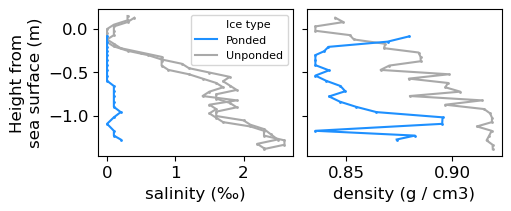

In [16]:
# Plot just floe 3 visit c

# Plot all salinities and densities
mpl.rcParams["font.size"] = 12
l_fs = 8

f, axs = plt.subplots(1, 2, sharex='col', sharey='row', figsize=(5, 2), constrained_layout=True)

kind = 'center'
markersize = 1

df_temp = df_cores.query('station=="3" & visit=="c"').reset_index()
for tup in df_temp.itertuples():
    ic = tup[4]
    if ic.ponded:
        c = 'C0'
    else:
        c = 'C1'
    if 'salinity' in ic.units:
        #print(tup[3])
        ic.plot_profile(axs[0], 'salinity', z_ref='sea surface',
                        color=c, 
                       kind=kind, markersize=markersize)
    if 'density' in ic.units:
        #print(tup[3])
        ic.plot_profile(axs[1], 'density', z_ref='sea surface',
                        color=c,
                       kind=kind, markersize=markersize)

axs[1].set_ylabel("")
axs[0].set_ylabel("Height from\nsea surface (m)")

# legends
h = [mlines.Line2D([], [], color='blue', linestyle='', label='Ice type'),
     mlines.Line2D([], [], color='C0', linestyle='-', label='Ponded'),
     mlines.Line2D([], [], color='C1', linestyle='-', label='Unponded')]
axs[0].legend(handles=h, loc='upper right', fontsize=l_fs)

f.savefig(os.path.join('..', 'figures', 'contrasts_r3c_cores_arc_sys_sci.png'),
          transparent=True, bbox_inches='tight')

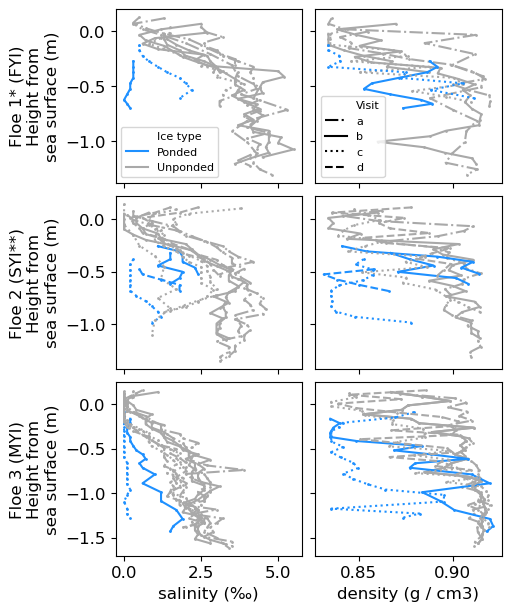

In [17]:
# Plot all salinities and densities
mpl.rcParams["font.size"] = 12
l_fs = 8

f, axs = plt.subplots(3, 2, sharex='col', sharey='row', figsize=(5, 6), constrained_layout=True)

stations = ['1', '2', '3']

style_dict = {'a': '-.',
              'b': '-',
              'c': ':',
              'd': '--',
             }

kind = 'center'
markersize = 1

for i, station in enumerate(stations):
    df_temp = df_cores.query('station == @station').reset_index()
    for tup in df_temp.itertuples():
        if tup[3] == '20250730-PS149_25-1-SI_corer_9cm-021-SMYI-RHO':
            continue # input is missing draft and freeboard, skip for now
        
        visit = tup[2]
        ic = tup[4]
        if ic.ponded:
            c = 'C0'
        else:
            c = 'C1'
        if 'salinity' in ic.units:
            #print(tup[3])
            ic.plot_profile(axs[i,0], 'salinity', z_ref='sea surface',
                            color=c, linestyle=style_dict[visit],
                           kind=kind, markersize=markersize)
        if 'density' in ic.units:
            #print(tup[3])
            ic.plot_profile(axs[i,1], 'density', z_ref='sea surface',
                            color=c, linestyle=style_dict[visit],
                           kind=kind, markersize=markersize)

for i in [0, 1, 2]:
    axs[i,1].set_ylabel("")
for i in [0, 1]:
    axs[0,i].set_xlabel("")
    axs[1,i].set_xlabel("")

axs[0,0].set_ylabel("Floe 1* (FYI)\nHeight from\nsea surface (m)")
axs[1,0].set_ylabel("Floe 2 (SYI**)\nHeight from\nsea surface (m)")
axs[2,0].set_ylabel("Floe 3 (MYI)\nHeight from\nsea surface (m)")

# legends
h = [mlines.Line2D([], [], color='blue', linestyle='', label='Ice type'),
     mlines.Line2D([], [], color='C0', linestyle='-', label='Ponded'),
     mlines.Line2D([], [], color='C1', linestyle='-', label='Unponded')]
axs[0,0].legend(handles=h, loc='lower left', fontsize=l_fs)
h = [mlines.Line2D([], [], color='blue', linestyle='', label='Visit'),
     mlines.Line2D([], [], color='k', linestyle='-.', label='a'),
     mlines.Line2D([], [], color='k', linestyle='-', label='b'),
     mlines.Line2D([], [], color='k', linestyle=':', label='c'),
     mlines.Line2D([], [], color='k', linestyle='--', label='d')]
axs[0,1].legend(handles=h, loc='lower left', fontsize=l_fs)

f.savefig(os.path.join('..', 'figures', 'contrasts_allcores_arc_sys_sci.png'),
          transparent=True, bbox_inches='tight')

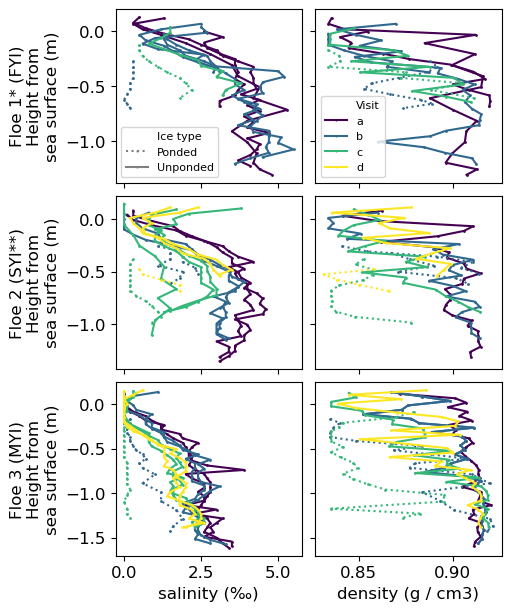

In [34]:
# Plot all salinities and densities
mpl.rcParams["font.size"] = 12
l_fs = 8

f, axs = plt.subplots(3, 2, sharex='col', sharey='row', figsize=(5, 6), constrained_layout=True)

stations = ['1', '2', '3']

style_dict = {'a': '-.',
              'b': '-',
              'c': ':',
              'd': '--',
             }
cmap = mpl.colormaps['viridis']
color_dict = {'a': cmap(0.0),#'tab:blue',
              'b': cmap(1.0/3.0),#'tab:orange',
              'c': cmap(2.0/3.0),#'tab:green',
              'd': cmap(1.0),#'tab:purple',
             }

kind = 'center'
markersize = 1

for i, station in enumerate(stations):
    df_temp = df_cores.query('station == @station').reset_index()
    for tup in df_temp.itertuples():
        if tup[3] == '20250730-PS149_25-1-SI_corer_9cm-021-SMYI-RHO':
            continue # input is missing draft and freeboard, skip for now
        
        visit = tup[2]
        ic = tup[4]
        if ic.ponded:
            style = ':'
        else:
            style = '-'
        if 'salinity' in ic.units:
            #print(tup[3])
            ic.plot_profile(axs[i,0], 'salinity', z_ref='sea surface',
                            color=color_dict[visit], linestyle=style,
                           kind=kind, markersize=markersize)
        if 'density' in ic.units:
            #print(tup[3])
            ic.plot_profile(axs[i,1], 'density', z_ref='sea surface',
                            color=color_dict[visit], linestyle=style,
                           kind=kind, markersize=markersize)

for i in [0, 1, 2]:
    axs[i,1].set_ylabel("")
for i in [0, 1]:
    axs[0,i].set_xlabel("")
    axs[1,i].set_xlabel("")

axs[0,0].set_ylabel("Floe 1* (FYI)\nHeight from\nsea surface (m)")
axs[1,0].set_ylabel("Floe 2 (SYI**)\nHeight from\nsea surface (m)")
axs[2,0].set_ylabel("Floe 3 (MYI)\nHeight from\nsea surface (m)")

# legends
h = [mlines.Line2D([], [], color='blue', linestyle='', label='Ice type'),
     mlines.Line2D([], [], color='grey', linestyle=':', marker='.', markersize=markersize, label='Ponded'),
     mlines.Line2D([], [], color='grey', linestyle='-', marker='.', markersize=markersize, label='Unponded')]
axs[0,0].legend(handles=h, loc='lower left', fontsize=l_fs)
h = [mlines.Line2D([], [], color='blue', linestyle='', label='Visit'),
     mlines.Line2D([], [], color=color_dict['a'], linestyle='-', marker='.', markersize=markersize, label='a'),
     mlines.Line2D([], [], color=color_dict['b'], linestyle='-', marker='.', markersize=markersize, label='b'),
     mlines.Line2D([], [], color=color_dict['c'], linestyle='-', marker='.', markersize=markersize, label='c'),
     mlines.Line2D([], [], color=color_dict['d'], linestyle='-', marker='.', markersize=markersize, label='d')]
axs[0,1].legend(handles=h, loc='lower left', fontsize=l_fs)

f.savefig(os.path.join('..', 'figures', 'contrasts_allcores_visit_color.png'),
          transparent=True, bbox_inches='tight')

## Per category thickness vs pond depth and depth vs fraction



In [8]:
df_trn_all.PondDepth.notna().sum()

np.int64(1413)

In [9]:
# Create variables for ponded ice fraction and split into thickness category
df_trn_all['Ponded'] = df_trn_all.PondDepth.notna()
df_trn_all['cat'] = pd.cut(df_trn_all.IceThickness, [0.0, 0.6, 1.4, 2.4, 3.6, np.inf], right=False)

In [10]:
# Group by floe, visit, category and create summary statistics
gps = df_trn_all[['SnowDepth', 'PondDepth', 'floe', 'visit',
       'IceThickness', 'Ponded', 'cat']].groupby(['floe', 'visit', 'cat'], observed=True)
df_trn_itd = pd.merge(gps.mean(),
    (gps.size()/df_trn_all.groupby(['floe','visit']).size()).rename('aicen_ai'),
                      left_index=True, right_index=True)
df_trn_itd.rename(columns={'Ponded':'PondArea'}, inplace=True)
df_trn_itd['PondVolume'] = df_trn_itd.PondDepth*df_trn_itd.PondArea

In [13]:
df_trn_itd

SnowDepth  PondDepth  IceThickness  PondArea  aicen_ai  \
floe visit cat                                                                  
1    a     [0.0, 0.6)   0.108532   0.150632      0.556394  0.500000  0.009456   
           [0.6, 1.4)   0.074098   0.143709      1.052027  0.156627  0.196217   
           [1.4, 2.4)   0.080249   0.117584      1.700077  0.348361  0.576832   
           [2.4, 3.6)   0.142516   0.126165      2.903758  0.051724  0.137116   
           [3.6, inf)   0.145668        NaN      4.964097  0.000000  0.080378   
     b     [0.0, 0.6)        NaN   0.234472      0.568381  1.000000  0.008715   
           [0.6, 1.4)   0.105426   0.187898      1.008688  0.215909  0.575163   
           [1.4, 2.4)   0.117704   0.189961      1.816636  0.150000  0.261438   
           [2.4, 3.6)   0.119087   0.225405      2.753906  0.044776  0.145969   
           [3.6, inf)   0.269522        NaN      4.218687  0.000000  0.008715   
     c     [0.0, 0.6)   0.077127   0.154466      0.475772  0.525547  0.408346   
           [0.6, 1.4)   0.076697   0.135527      0.865339  0.196078  0.532042   
           [1.4, 2.4)   0.079981   0.067980      1.528621  0.050000  0.059613   
2    a     [0.6, 1.4)   0.096039   0.130052      1.230523  0.335821  0.220758   
           [1.4, 2.4)   0.089662   0.104742      1.729027  0.165414  0.657331   
           [2.4, 3.6)   0.147982   0.065977      2.923272  0.021277  0.077430   
           [3.6, inf)   0.215073   0.153377      4.067679  0.037037  0.044481   
     c     [0.0, 0.6)   0.292317   0.301317      0.581752  0.500000  0.001974   
           [0.6, 1.4)   0.081095   0.212813      1.086162  0.397101  0.681145   
           [1.4, 2.4)   0.076689   0.179002      1.605897  0.087542  0.293189   
           [2.4, 3.6)   0.120203   0.192292      2.867964  0.083333  0.023692   
     d     [0.0, 0.6)        NaN   0.342300      0.493248  1.000000  0.001404   
           [0.6, 1.4)   0.046235   0.025449      1.010150  0.246679  0.740169   
           [1.4, 2.4)   0.042912   0.010346      1.690232  0.198795  0.233146   
           [2.4, 3.6)   0.051740   0.010000      2.577729  0.055556  0.025281   
3    a     [0.6, 1.4)   0.207217   0.180717      1.333417  0.500000  0.004145   
           [1.4, 2.4)   0.110716   0.130139      1.952580  0.123512  0.696373   
           [2.4, 3.6)   0.125177   0.144772      2.842986  0.066148  0.266321   
           [3.6, inf)   0.146424        NaN      4.423251  0.000000  0.033161   
     b     [0.6, 1.4)   0.066984   0.187973      1.324719  0.450000  0.078431   
           [1.4, 2.4)   0.069048   0.138440      1.781486  0.241252  0.709804   
           [2.4, 3.6)   0.067246   0.116800      2.844125  0.105263  0.124183   
           [3.6, inf)   0.156107   0.284375      4.494612  0.059701  0.087582   
     c     [0.0, 0.6)        NaN   1.109983      0.438128  1.000000  0.003802   
           [0.6, 1.4)   0.089875   0.205986      1.276089  0.446281  0.153359   
           [1.4, 2.4)   0.080936   0.178465      1.714837  0.174545  0.697085   
           [2.4, 3.6)   0.112066   0.161538      2.866764  0.038835  0.130545   
           [3.6, inf)   0.175520        NaN      4.289063  0.000000  0.015209   

                       PondVolume  
floe visit cat                     
1    a     [0.0, 0.6)    0.075316  
           [0.6, 1.4)    0.022509  
           [1.4, 2.4)    0.040962  
           [2.4, 3.6)    0.006526  
           [3.6, inf)         NaN  
     b     [0.0, 0.6)    0.234472  
           [0.6, 1.4)    0.040569  
           [1.4, 2.4)    0.028494  
           [2.4, 3.6)    0.010093  
           [3.6, inf)         NaN  
     c     [0.0, 0.6)    0.081179  
           [0.6, 1.4)    0.026574  
           [1.4, 2.4)    0.003399  
2    a     [0.6, 1.4)    0.043674  
           [1.4, 2.4)    0.017326  
           [2.4, 3.6)    0.001404  
           [3.6, inf)    0.005681  
     c     [0.0, 0.6)    0.150658  
           [0.6, 1.4)    0.084508  
           [1.4, 2.4)    0

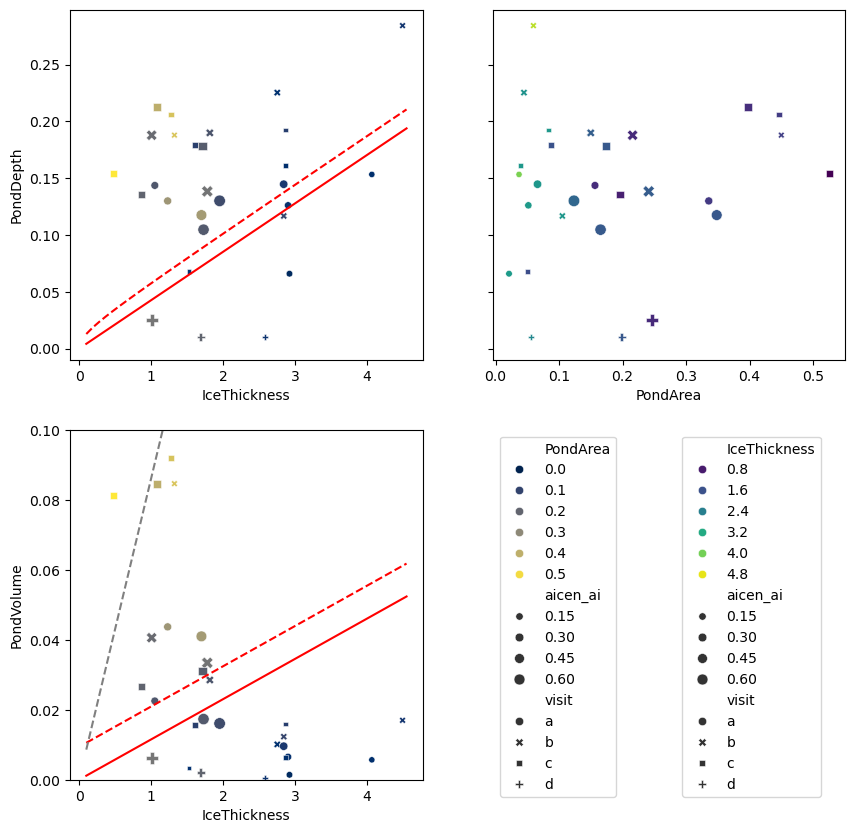

In [20]:
# code for sealvl ponds when the ponds are at sea level
apnd_sl = 0.27
hi_min = 0.10
hi_max = 4.55
hi = np.linspace(hi_min, hi_max)
rhow = 1026.0
rhosi = 940.0
rhofresh = 1000.0
df_sealvl = pd.DataFrame({'apnd_sl': apnd_sl,
                          'hi': hi,
                          'pndasp': hi*(rhow - rhosi) / (rhofresh*apnd_sl**2 - 2*rhow*apnd_sl + rhow)})
df_sealvl['hp_sl'] = df_sealvl.apnd_sl * df_sealvl.pndasp
df_sealvl['vp_sl'] = df_sealvl.apnd_sl * df_sealvl.hp_sl
# maybe at some point could look at deviations as a function of melt rate
# for now look at what happens if ponds are 1 cm of ice surface melt above sealevel value
# as a crude kind of dynamic equilibrium
df_sealvl['vp_1cm_d'] = 0.01*rhosi/rhofresh + df_sealvl['vp_sl']
df_sealvl['ap_1cm_d'] = np.sqrt(df_sealvl.vp_1cm_d/df_sealvl.pndasp)
df_sealvl['hp_1cm_d'] = df_sealvl.ap_1cm_d * df_sealvl.pndasp
# estimate max possible vp due to buoyancy
df_sealvl['vp_max'] = df_sealvl.hi*(rhow - rhosi)/rhofresh

f, axs = plt.subplots(2, 2, sharey='row', figsize=(10, 10))
axs[1,1].set_axis_off()

min_aicen = 0.01
palette_hi = 'viridis'
palette_ap = 'cividis'
style_order = ['a', 'b', 'c', 'd']

h_ap = sns.scatterplot(x='IceThickness', y='PondDepth', hue='PondArea', size='aicen_ai', 
                       style='visit', style_order=style_order,
                       data=df_trn_itd.loc[df_trn_itd.aicen_ai>min_aicen, :],
                       palette=palette_ap, ax=axs[0,0],
                       legend=True)
sns.move_legend(h_ap, "upper left", bbox_to_anchor=(1.2,-0.2))

h_hi = sns.scatterplot(x='PondArea', y='PondDepth', hue='IceThickness', size='aicen_ai', 
                       style='visit', style_order=style_order,
                       data=df_trn_itd.loc[df_trn_itd.aicen_ai>min_aicen, :],
                       palette=palette_hi, ax=axs[0,1],
                       legend=True)
sns.move_legend(h_hi, "upper right", bbox_to_anchor=(0.95,-0.2))


axs[0,0].plot('hi', 'hp_sl', data=df_sealvl, c='r', ls='-')
axs[0,0].plot('hi', 'hp_1cm_d', data=df_sealvl, c='r', ls='--')

h_vp = sns.scatterplot(x='IceThickness', y='PondVolume', hue='PondArea', size='aicen_ai', 
                       style='visit', style_order=style_order,
                       data=df_trn_itd.loc[df_trn_itd.aicen_ai>min_aicen, :],
                       palette=palette_ap, ax=axs[1,0],
                       legend=False)
axs[1,0].plot('hi', 'vp_sl', data=df_sealvl, c='r', ls='-')
axs[1,0].plot('hi', 'vp_1cm_d', data=df_sealvl, c='r', ls='--')
axs[1,0].plot('hi', 'vp_max', data=df_sealvl, c='grey', ls='--')

axs[1,0].set_ylim([0, 0.1])

#axs[0].set_ylim([0, 0.35])
#axs[0].set_xlim([0, 4.6])
#axs[1].set_xlim([0, 0.55])

#f.colorbar(h_ap, ax=axs[0], orientation='horizontal', shrink=0.8, label='Pond area fraction')

#f.colorbar(h_hi, ax=axs[1], orientation='horizontal', shrink=0.8, label='Ice thickness (m)')

f.savefig(os.path.join('..', 'figures', 'contrasts_meltponds_itd.png'),
          transparent=True, bbox_inches='tight')

<Axes: xlabel='IceThickness', ylabel='PondDepth'>

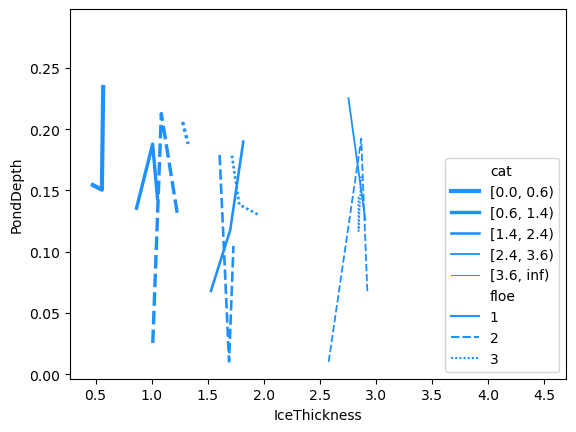

In [17]:
sns.lineplot(x='IceThickness', y='PondDepth', size='cat', 
                       style='floe',
                       data=df_trn_itd.loc[df_trn_itd.aicen_ai>min_aicen, :],
                       legend=True)

In [161]:
# estimate max possible vp due to buoyancy
df_sealvl['vp_max'] = df_sealvl.hi*(rhow - rhosi)/rhofresh

0     0.008600
1     0.016410
2     0.024220
3     0.032031
4     0.039841
5     0.047651
6     0.055461
7     0.063271
8     0.071082
9     0.078892
10    0.086702
11    0.094512
12    0.102322
13    0.110133
14    0.117943
15    0.125753
16    0.133563
17    0.141373
18    0.149184
19    0.156994
20    0.164804
21    0.172614
22    0.180424
23    0.188235
24    0.196045
25    0.203855
26    0.211665
27    0.219476
28    0.227286
29    0.235096
30    0.242906
31    0.250716
32    0.258527
33    0.266337
34    0.274147
35    0.281957
36    0.289767
37    0.297578
38    0.305388
39    0.313198
40    0.321008
41    0.328818
42    0.336629
43    0.344439
44    0.352249
45    0.360059
46    0.367869
47    0.375680
48    0.383490
49    0.391300
Name: hi, dtype: float64

In [53]:
help(f.colorbar)

Help on method colorbar in module matplotlib.figure:

colorbar(mappable, cax=None, ax=None, use_gridspec=True, **kwargs) method of matplotlib.figure.Figure instance
    Add a colorbar to a plot.

    Parameters
    ----------
    mappable
        The `matplotlib.cm.ScalarMappable` (i.e., `.AxesImage`,
        `.ContourSet`, etc.) described by this colorbar.  This argument is
        mandatory for the `.Figure.colorbar` method but optional for the
        `.pyplot.colorbar` function, which sets the default to the current
        image.

        Note that one can create a `.ScalarMappable` "on-the-fly" to
        generate colorbars not attached to a previously drawn artist, e.g.
        ::

            fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)

    cax : `~matplotlib.axes.Axes`, optional
        Axes into which the colorbar will be drawn.  If `None`, then a new
        Axes is created and the space for it will be stolen from the Axes(s)
        specified in *ax*.

    